# 🎬 Movie Success Prediction — Notebook 04: SQL-Based Data Extraction

**Goal:** Use SQL (via SQLite in-memory) to query, aggregate, and extract meaningful subsets of the movie dataset — simulating how a data team would query a production database.

**Input:** `movies.csv`  
**Output:** SQL-derived tables + visualisations, exported CSVs per query

> 💡 No database server needed — we use Python's built-in `sqlite3` with an in-memory database.

---

## 1. Setup & Load Data into SQLite

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Helper function — run any SQL and return a DataFrame
def sql(query, conn, verbose=True):
    df_result = pd.read_sql_query(query, conn)
    if verbose:
        print(f'Rows returned: {len(df_result)}')
    return df_result

print('Imports done ✅')

Imports done ✅


In [4]:
# Load Excel
df = pd.read_excel('/content/movies_cleaned.xlsx')

# ── Feature engineering before pushing to SQL
df['roi']    = df['gross'] / df['budget']           # Return on investment
df['profit'] = df['gross'] - df['budget']           # Absolute profit
df['decade'] = (df['year'] // 10 * 10).astype('Int64').astype(str) + 's'

# Hit flag: ROI ≥ 2x AND score ≥ 7.0
df['hit'] = ((df['roi'] >= 2.0) & (df['score'] >= 7.0)).astype(int)

# Clean rating
valid_ratings = ['G', 'PG', 'PG-13', 'R']
df['rating_clean'] = df['rating'].where(df['rating'].isin(valid_ratings), 'Other')

# ── Push to in-memory SQLite
conn = sqlite3.connect(':memory:')
df.to_sql('movies', conn, index=False, if_exists='replace')

# Verify
count = pd.read_sql_query('SELECT COUNT(*) AS total FROM movies', conn).iloc[0, 0]
print(f'\nTable "movies" loaded into SQLite — {count} rows')
print(f'Columns: {df.columns.tolist()}')


Table "movies" loaded into SQLite — 5475 rows
Columns: ['Unnamed: 0', 'name', 'rating', 'genre', 'year', 'released', 'score', 'votes', 'director', 'writer', 'star', 'country', 'budget', 'gross', 'company', 'runtime', 'release_month', 'release_day', 'roi', 'roi_class', 'profit', 'decade', 'hit', 'rating_clean']


In [5]:
# Preview the schema and first rows via SQL
sql("SELECT name, genre, year, rating_clean, score, budget, gross, roi, hit FROM movies LIMIT 5", conn)

Rows returned: 5


,name,genre,year,rating_clean,score,budget,gross,roi,hit
0,The Blue Lagoon,Adventure,1980,R,5.8,4500000.0,58853106.0,13.078468,0
1,Star Wars: Episode V - The Empire Strikes Back,Action,1980,PG,8.7,18000000.0,538375067.0,29.909726,1
2,Airplane!,Comedy,1980,PG,7.7,3500000.0,83453539.0,23.843868,1
3,Caddyshack,Comedy,1980,R,7.3,6000000.0,39846344.0,6.641057,1
4,Friday the 13th,Horror,1980,R,6.4,550000.0,39754601.0,72.281093,0


---
## Query 1 — Top 10 Highest-Grossing Movies Overall

Rows returned: 10


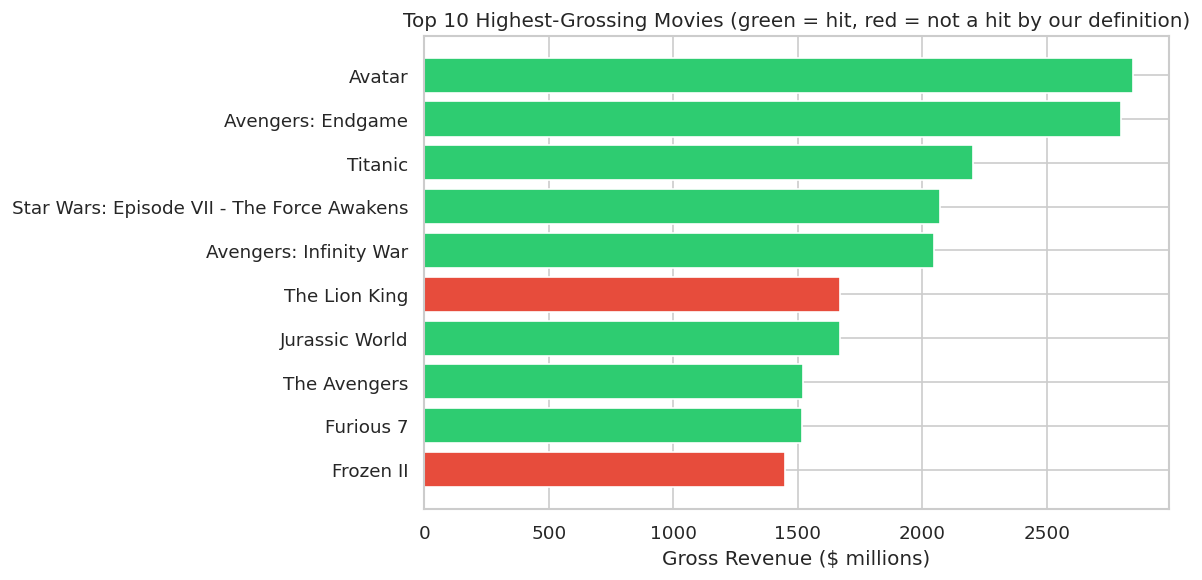

,name,genre,year,budget_M,gross_M,roi,score,hit
0,Avatar,Action,2009,237.0,2847.2,12.01,7.8,1
1,Avengers: Endgame,Action,2019,356.0,2797.5,7.86,8.4,1
2,Titanic,Drama,1997,200.0,2201.6,11.01,7.8,1
3,Star Wars: Episode VII - The Force Awakens,Action,2015,245.0,2069.5,8.45,7.8,1
4,Avengers: Infinity War,Action,2018,321.0,2048.4,6.38,8.4,1
5,The Lion King,Animation,2019,260.0,1670.7,6.43,6.9,0
6,Jurassic World,Action,2015,150.0,1670.5,11.14,7.0,1
7,The Avengers,Action,2012,220.0,1518.8,6.90,8.0,1
8,Furious 7,Action,2015,190.0,1515.3,7.98,7.1,1
9,Frozen II,Animation,2019,150.0,1450.0,9.67,6.8,0


In [6]:
q1 = sql("""
    SELECT
        name,
        genre,
        year,
        ROUND(budget / 1e6, 1)  AS budget_M,
        ROUND(gross / 1e6, 1)   AS gross_M,
        ROUND(roi, 2)           AS roi,
        score,
        hit
    FROM movies
    WHERE gross IS NOT NULL
    ORDER BY gross DESC
    LIMIT 10
""", conn)

q1.to_csv('sql_top10_grossing.csv', index=False)

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if h else '#e74c3c' for h in q1['hit']]
ax.barh(q1['name'], q1['gross_M'], color=colors)
ax.set_xlabel('Gross Revenue ($ millions)')
ax.set_title('Top 10 Highest-Grossing Movies (green = hit, red = not a hit by our definition)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('sql_top10_grossing.png', bbox_inches='tight')
plt.show()

q1

---
## Query 2 — Hit Rate and Average ROI by Genre

Rows returned: 9


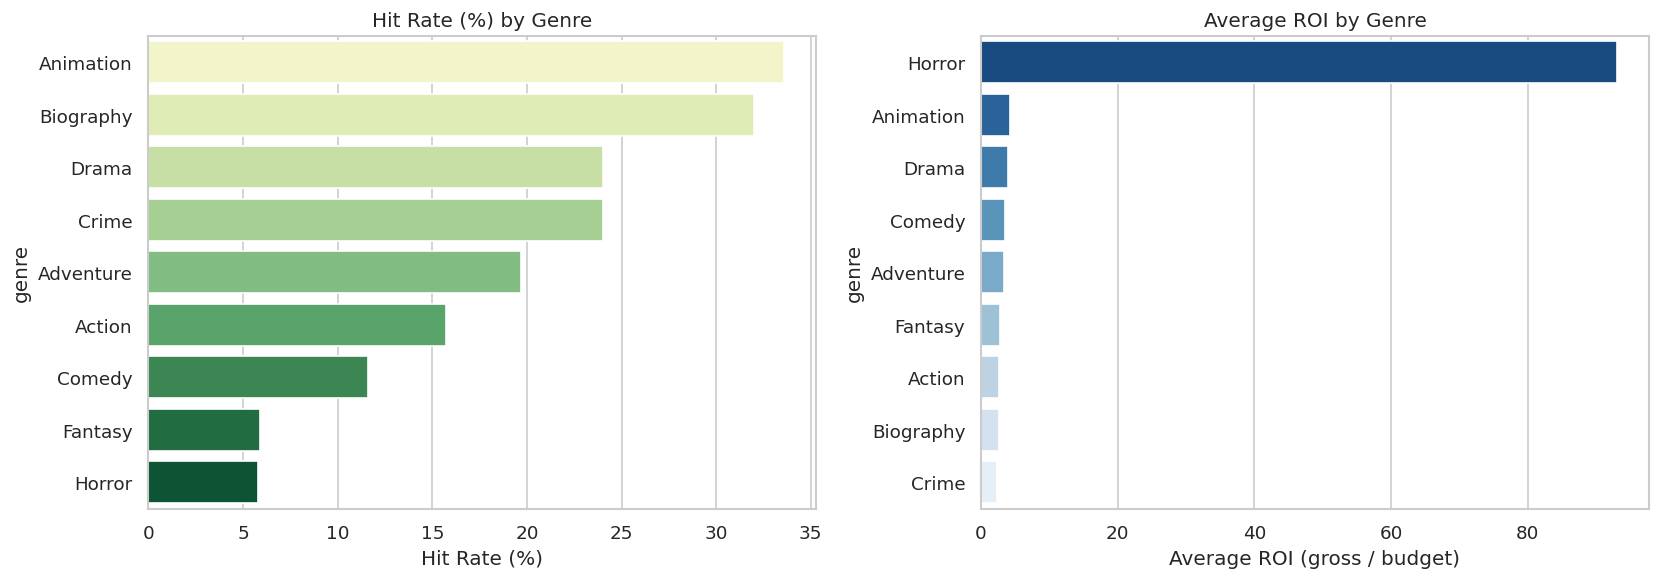

,genre,total_movies,total_hits,hit_rate_pct,avg_score,avg_gross_M,avg_roi
0,Animation,214,72,33.6,6.70,334.7,4.16
1,Biography,206,66,32.0,7.07,66.1,2.66
2,Drama,630,151,24.0,6.64,68.4,3.88
3,Crime,312,75,24.0,6.68,54.9,2.35
4,Adventure,229,45,19.7,6.20,111.2,3.41
5,Action,1150,180,15.7,6.21,175.5,2.68
6,Comedy,1313,152,11.6,6.15,60.9,3.43
7,Fantasy,34,2,5.9,5.91,43.0,2.75
8,Horror,206,12,5.8,5.77,58.9,93.07


In [7]:
q2 = sql("""
    SELECT
        genre,
        COUNT(*)                        AS total_movies,
        SUM(hit)                        AS total_hits,
        ROUND(AVG(hit) * 100, 1)        AS hit_rate_pct,
        ROUND(AVG(score), 2)            AS avg_score,
        ROUND(AVG(gross) / 1e6, 1)      AS avg_gross_M,
        ROUND(AVG(roi), 2)              AS avg_roi
    FROM movies
    WHERE budget IS NOT NULL
      AND gross  IS NOT NULL
      AND score  IS NOT NULL
    GROUP BY genre
    HAVING total_movies >= 30
    ORDER BY hit_rate_pct DESC
""", conn)

q2.to_csv('sql_genre_hit_rate.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=q2, x='hit_rate_pct', y='genre', palette='YlGn', ax=axes[0])
axes[0].set_title('Hit Rate (%) by Genre')
axes[0].set_xlabel('Hit Rate (%)')

sns.barplot(data=q2.sort_values('avg_roi', ascending=False),
            x='avg_roi', y='genre', palette='Blues_r', ax=axes[1])
axes[1].set_title('Average ROI by Genre')
axes[1].set_xlabel('Average ROI (gross / budget)')

plt.tight_layout()
plt.savefig('sql_genre_hit_rate.png', bbox_inches='tight')
plt.show()

q2

---
## Query 3 — Average ROI and Hit Rate by Rating (G / PG / PG-13 / R)

Rows returned: 5


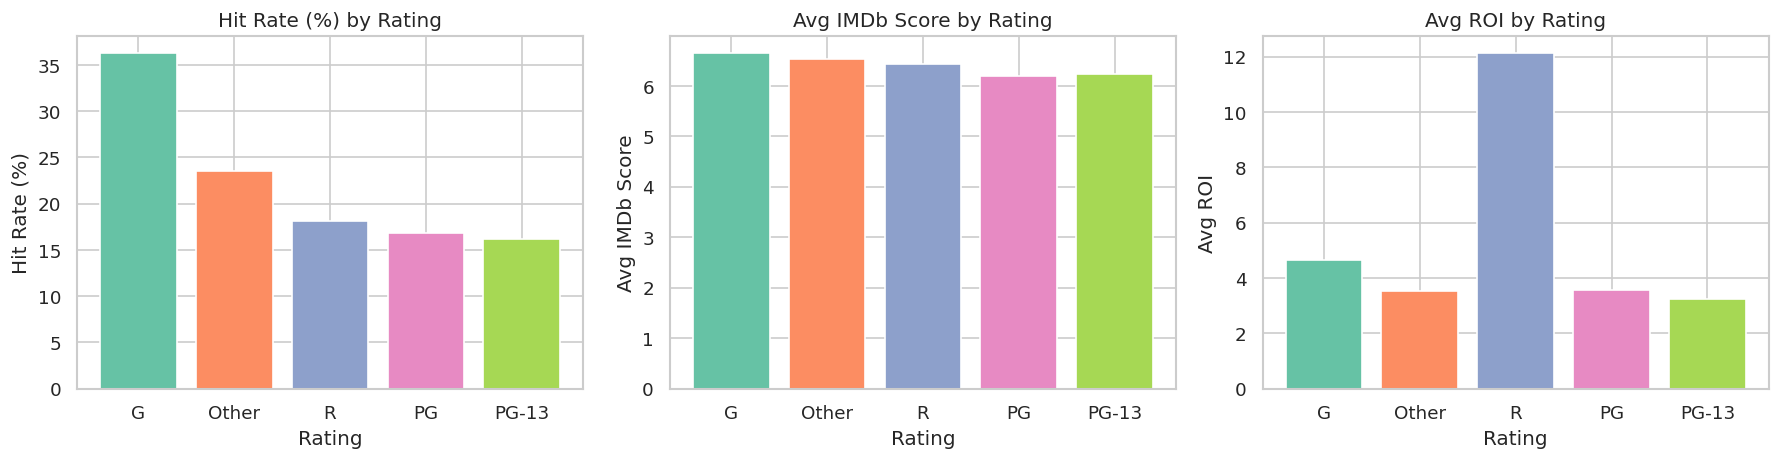

,rating,total_movies,hit_rate_pct,avg_score,avg_roi,avg_gross_M,avg_budget_M
0,G,80,36.3,6.65,4.64,235.8,64.3
1,Other,34,23.5,6.54,3.52,5.4,3.2
2,R,2034,18.1,6.44,12.13,59.8,23.9
3,PG,730,16.8,6.19,3.56,146.3,45.1
4,PG-13,1448,16.2,6.23,3.22,154.4,51.6


In [8]:
q3 = sql("""
    SELECT
        rating_clean                    AS rating,
        COUNT(*)                        AS total_movies,
        ROUND(AVG(hit) * 100, 1)        AS hit_rate_pct,
        ROUND(AVG(score), 2)            AS avg_score,
        ROUND(AVG(roi), 2)              AS avg_roi,
        ROUND(AVG(gross) / 1e6, 1)      AS avg_gross_M,
        ROUND(AVG(budget) / 1e6, 1)     AS avg_budget_M
    FROM movies
    WHERE budget IS NOT NULL
      AND gross  IS NOT NULL
    GROUP BY rating_clean
    ORDER BY hit_rate_pct DESC
""", conn)

q3.to_csv('sql_rating_analysis.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes,
                           ['hit_rate_pct', 'avg_score', 'avg_roi'],
                           ['Hit Rate (%)', 'Avg IMDb Score', 'Avg ROI']):
    bars = ax.bar(q3['rating'], q3[col], color=sns.color_palette('Set2', len(q3)))
    ax.set_title(f'{label} by Rating')
    ax.set_xlabel('Rating')
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig('sql_rating_analysis.png', bbox_inches='tight')
plt.show()

q3

---
## Query 4 — Directors with the Most Hits (min 3 movies)

Rows returned: 15


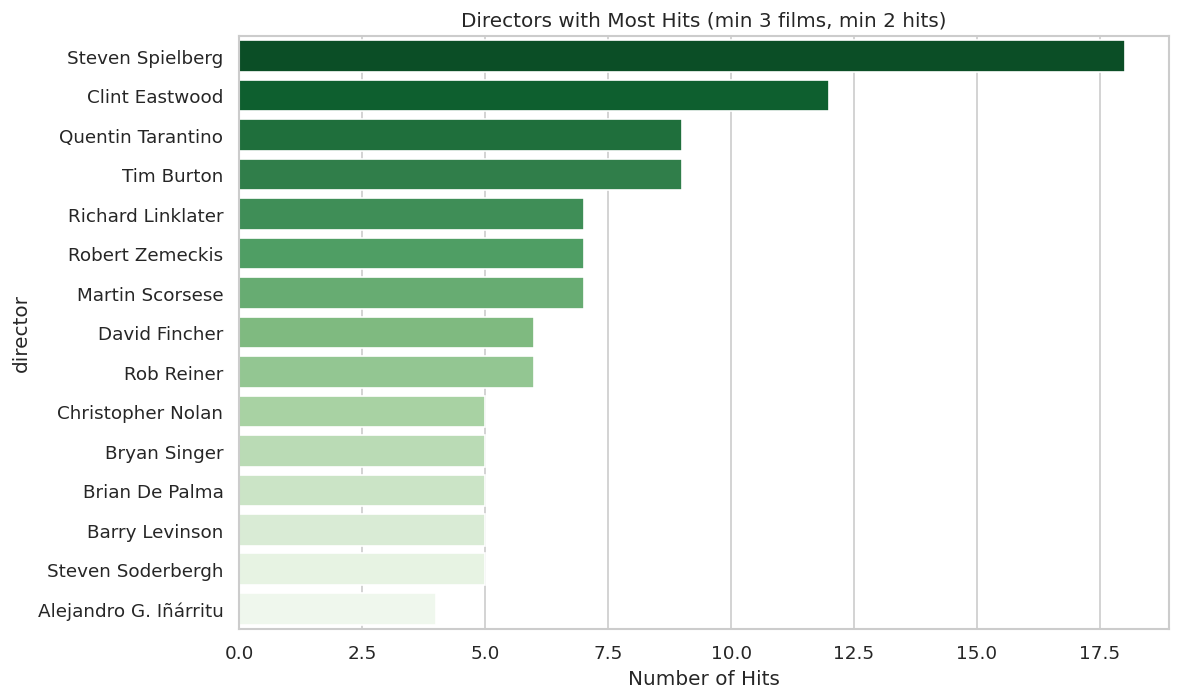

,director,total_movies,hit_count,hit_rate_pct,avg_score,avg_gross_M
0,Steven Spielberg,27,18,66.7,7.44,356.6
1,Clint Eastwood,30,12,40.0,6.93,100.2
2,Quentin Tarantino,9,9,100.0,8.10,207.8
3,Tim Burton,18,9,50.0,7.01,221.2
4,Richard Linklater,14,7,50.0,7.16,22.1
5,Robert Zemeckis,14,7,50.0,7.35,290.5
6,Martin Scorsese,17,7,41.2,7.69,111.7
7,David Fincher,9,6,66.7,7.64,226.8
8,Rob Reiner,14,6,42.9,6.89,68.2
9,Christopher Nolan,6,5,83.3,8.23,510.3


In [9]:
q4 = sql("""
    SELECT
        director,
        COUNT(*)                        AS total_movies,
        SUM(hit)                        AS hit_count,
        ROUND(AVG(hit) * 100, 1)        AS hit_rate_pct,
        ROUND(AVG(score), 2)            AS avg_score,
        ROUND(AVG(gross) / 1e6, 1)      AS avg_gross_M
    FROM movies
    WHERE budget IS NOT NULL
      AND gross  IS NOT NULL
    GROUP BY director
    HAVING total_movies >= 3
       AND hit_count    >= 2
    ORDER BY hit_count DESC, hit_rate_pct DESC
    LIMIT 15
""", conn)

q4.to_csv('sql_directors_hits.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=q4, x='hit_count', y='director', palette='Greens_r', ax=ax)
ax.set_title('Directors with Most Hits (min 3 films, min 2 hits)')
ax.set_xlabel('Number of Hits')
plt.tight_layout()
plt.savefig('sql_directors.png', bbox_inches='tight')
plt.show()

q4

---
## Query 5 — Decade-by-Decade Trends: Budget, Gross, Hit Rate

Rows returned: 5


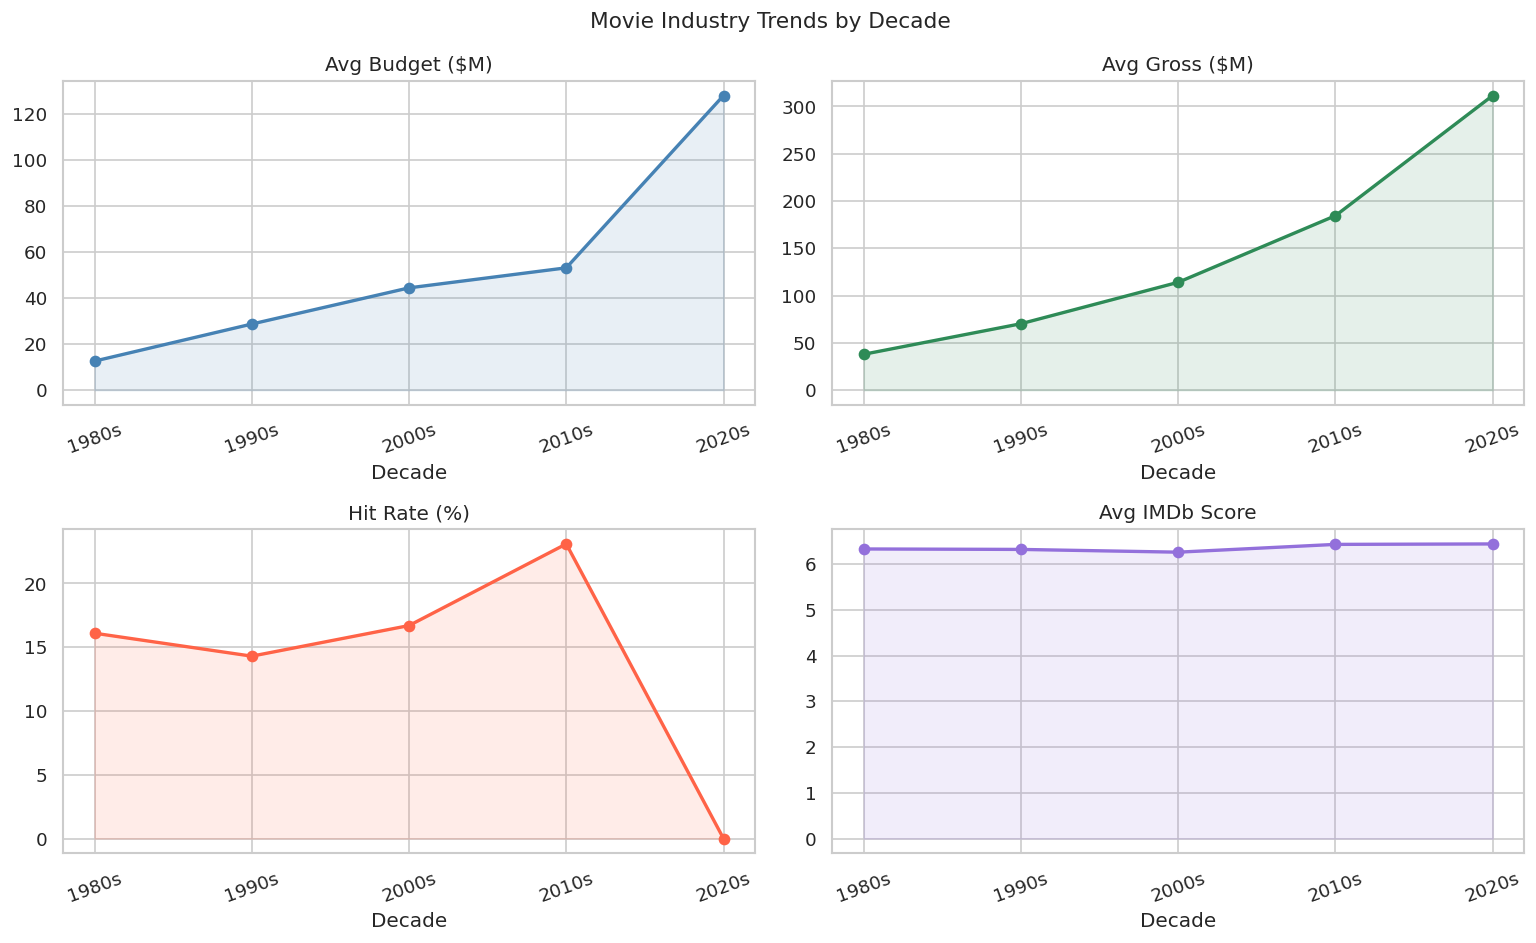

,decade,total_movies,hit_rate_pct,avg_score,avg_budget_M,avg_gross_M,avg_roi
0,1980s,731,16.1,6.33,12.6,37.9,3.85
1,1990s,1143,14.3,6.32,28.7,70.2,6.32
2,2000s,1277,16.7,6.26,44.4,114.0,13.21
3,2010s,1170,23.1,6.43,53.1,184.4,4.69
4,2020s,5,0.0,6.44,127.9,311.4,2.81


In [10]:
q5 = sql("""
    SELECT
        decade,
        COUNT(*)                        AS total_movies,
        ROUND(AVG(hit) * 100, 1)        AS hit_rate_pct,
        ROUND(AVG(score), 2)            AS avg_score,
        ROUND(AVG(budget) / 1e6, 1)     AS avg_budget_M,
        ROUND(AVG(gross) / 1e6, 1)      AS avg_gross_M,
        ROUND(AVG(roi), 2)              AS avg_roi
    FROM movies
    WHERE budget IS NOT NULL
      AND gross  IS NOT NULL
    GROUP BY decade
    ORDER BY decade
""", conn)

q5.to_csv('sql_decade_trends.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Movie Industry Trends by Decade', fontsize=13)

for ax, col, label, color in zip(
        axes.flatten(),
        ['avg_budget_M', 'avg_gross_M', 'hit_rate_pct', 'avg_score'],
        ['Avg Budget ($M)', 'Avg Gross ($M)', 'Hit Rate (%)', 'Avg IMDb Score'],
        ['steelblue', 'seagreen', 'tomato', 'mediumpurple']):
    ax.plot(q5['decade'], q5[col], marker='o', color=color, linewidth=2)
    ax.fill_between(q5['decade'], q5[col], alpha=0.12, color=color)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=20)
    ax.set_xlabel('Decade')

plt.tight_layout()
plt.savefig('sql_decade_trends.png', bbox_inches='tight')
plt.show()

q5

---
## Query 6 — Budget Tier Analysis: Low / Mid / High Budget

Rows returned: 4


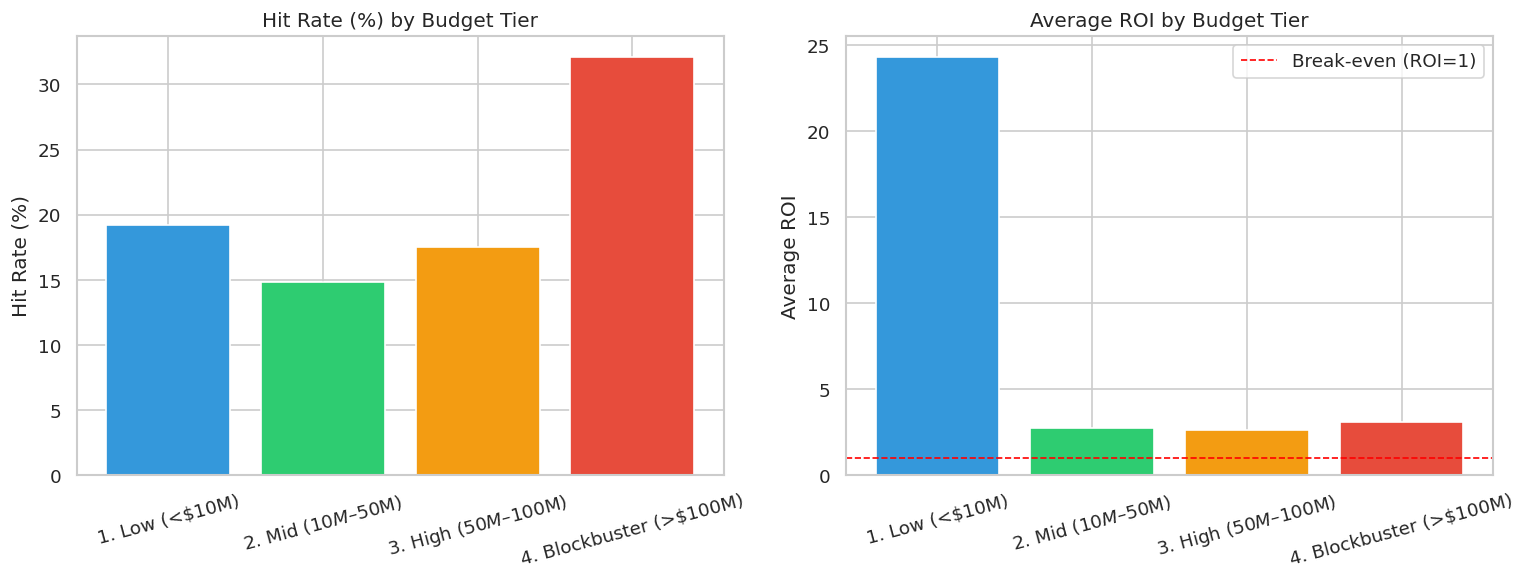

,budget_tier,total_movies,hit_rate_pct,avg_roi,avg_score,avg_gross_M
0,1. Low (<$10M),949,19.2,24.28,6.36,19.3
1,2. Mid ($10M–$50M),2318,14.8,2.76,6.28,63.6
2,3. High ($50M–$100M),685,17.5,2.65,6.33,180.7
3,4. Blockbuster (>$100M),374,32.1,3.11,6.62,485.0


In [11]:
q6 = sql("""
    SELECT
        CASE
            WHEN budget < 10000000  THEN '1. Low (<$10M)'
            WHEN budget < 50000000  THEN '2. Mid ($10M–$50M)'
            WHEN budget < 100000000 THEN '3. High ($50M–$100M)'
            ELSE                         '4. Blockbuster (>$100M)'
        END AS budget_tier,
        COUNT(*)                        AS total_movies,
        ROUND(AVG(hit) * 100, 1)        AS hit_rate_pct,
        ROUND(AVG(roi), 2)              AS avg_roi,
        ROUND(AVG(score), 2)            AS avg_score,
        ROUND(AVG(gross) / 1e6, 1)      AS avg_gross_M
    FROM movies
    WHERE budget IS NOT NULL
      AND gross  IS NOT NULL
    GROUP BY budget_tier
    ORDER BY budget_tier
""", conn)

q6.to_csv('sql_budget_tiers.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(q6['budget_tier'], q6['hit_rate_pct'], color=colors)
axes[0].set_title('Hit Rate (%) by Budget Tier')
axes[0].set_ylabel('Hit Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(q6['budget_tier'], q6['avg_roi'], color=colors)
axes[1].set_title('Average ROI by Budget Tier')
axes[1].set_ylabel('Average ROI')
axes[1].axhline(1.0, color='red', linestyle='--', linewidth=1, label='Break-even (ROI=1)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('sql_budget_tiers.png', bbox_inches='tight')
plt.show()

q6

---
## Query 7 — Top Production Companies by Total Gross

Rows returned: 12


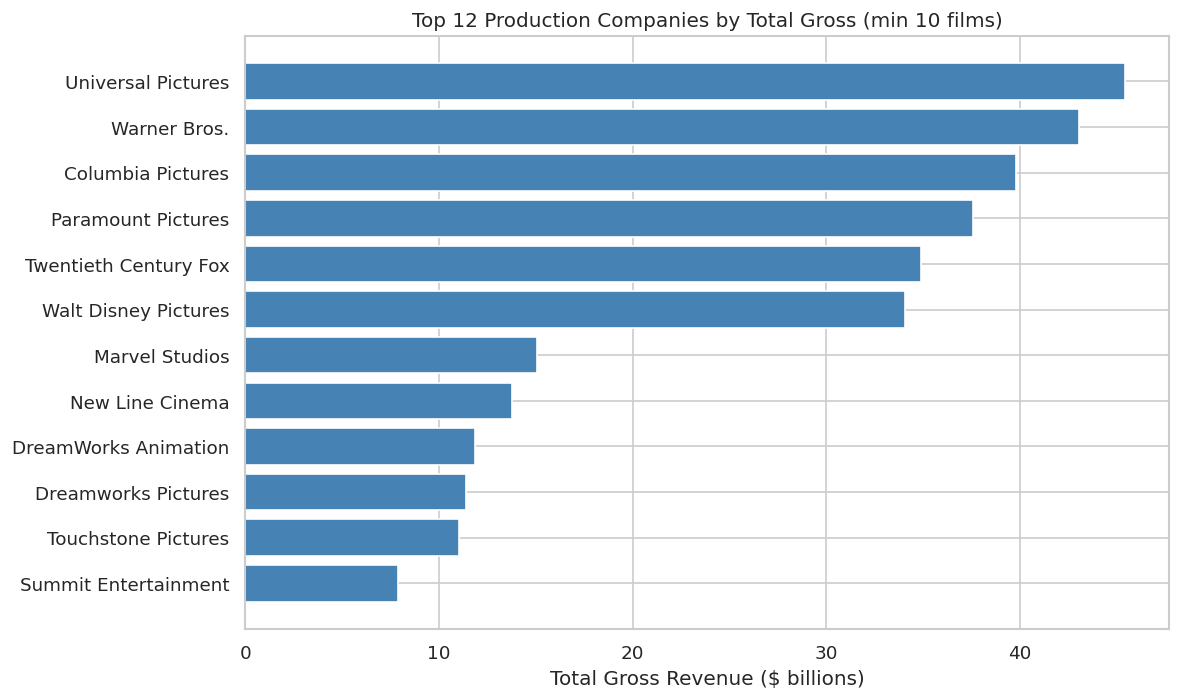

,company,total_movies,hit_count,hit_rate_pct,total_gross_B,avg_score
0,Universal Pictures,319,52,16.3,45.42,6.36
1,Warner Bros.,285,52,18.2,43.06,6.36
2,Columbia Pictures,298,46,15.4,39.78,6.30
3,Paramount Pictures,280,52,18.6,37.57,6.35
4,Twentieth Century Fox,221,39,17.6,34.87,6.21
5,Walt Disney Pictures,115,28,24.3,34.09,6.50
6,Marvel Studios,12,11,91.7,15.07,7.60
7,New Line Cinema,149,19,12.8,13.79,6.11
8,DreamWorks Animation,28,11,39.3,11.87,6.90
9,Dreamworks Pictures,73,24,32.9,11.40,6.70


In [12]:
q7 = sql("""
    SELECT
        company,
        COUNT(*)                          AS total_movies,
        SUM(hit)                          AS hit_count,
        ROUND(AVG(hit) * 100, 1)          AS hit_rate_pct,
        ROUND(SUM(gross) / 1e9, 2)        AS total_gross_B,
        ROUND(AVG(score), 2)              AS avg_score
    FROM movies
    WHERE gross IS NOT NULL
      AND company IS NOT NULL
    GROUP BY company
    HAVING total_movies >= 10
    ORDER BY total_gross_B DESC
    LIMIT 12
""", conn)

q7.to_csv('sql_top_companies.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(q7['company'], q7['total_gross_B'], color='steelblue')
ax.set_xlabel('Total Gross Revenue ($ billions)')
ax.set_title('Top 12 Production Companies by Total Gross (min 10 films)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('sql_top_companies.png', bbox_inches='tight')
plt.show()

q7

---
## Query 8 — High Score, Low Gross: Critical Hits that Didn't Sell

In [13]:
# Score ≥ 8.0 but gross < median gross — critically acclaimed but not commercially dominant
q8 = sql("""
    SELECT
        name,
        genre,
        year,
        score,
        votes,
        ROUND(gross / 1e6, 1)       AS gross_M,
        ROUND(budget / 1e6, 1)      AS budget_M,
        ROUND(roi, 2)               AS roi
    FROM movies
    WHERE score >= 8.0
      AND gross < (SELECT AVG(gross) FROM movies WHERE gross IS NOT NULL)
      AND gross IS NOT NULL
      AND budget IS NOT NULL
    ORDER BY score DESC
    LIMIT 15
""", conn)

q8.to_csv('sql_critical_hits.csv', index=False)
print('Critical hits (high score, below-average gross):')
q8

Rows returned: 15
Critical hits (high score, below-average gross):


,name,genre,year,score,votes,gross_M,budget_M,roi
0,The Shawshank Redemption,Drama,1994,9.3,2400000.0,28.8,25.0,1.15
1,Goodfellas,Biography,1990,8.7,1100000.0,47.0,25.0,1.88
2,The Usual Suspects,Crime,1995,8.5,1000000.0,23.3,6.0,3.89
3,American History X,Drama,1998,8.5,1100000.0,23.9,20.0,1.19
4,Whiplash,Drama,2014,8.5,749000.0,49.4,3.3,14.97
5,Memento,Mystery,2000,8.4,1200000.0,40.0,9.0,4.45
6,Scarface,Crime,1983,8.3,766000.0,65.9,25.0,2.64
7,Amadeus,Biography,1984,8.3,377000.0,52.1,18.0,2.89
8,Reservoir Dogs,Crime,1992,8.3,943000.0,2.9,1.2,2.43
9,Requiem for a Dream,Drama,2000,8.3,786000.0,7.4,4.5,1.64


---
## Query 9 — Genre × Rating Cross-Tabulation

Rows returned: 30


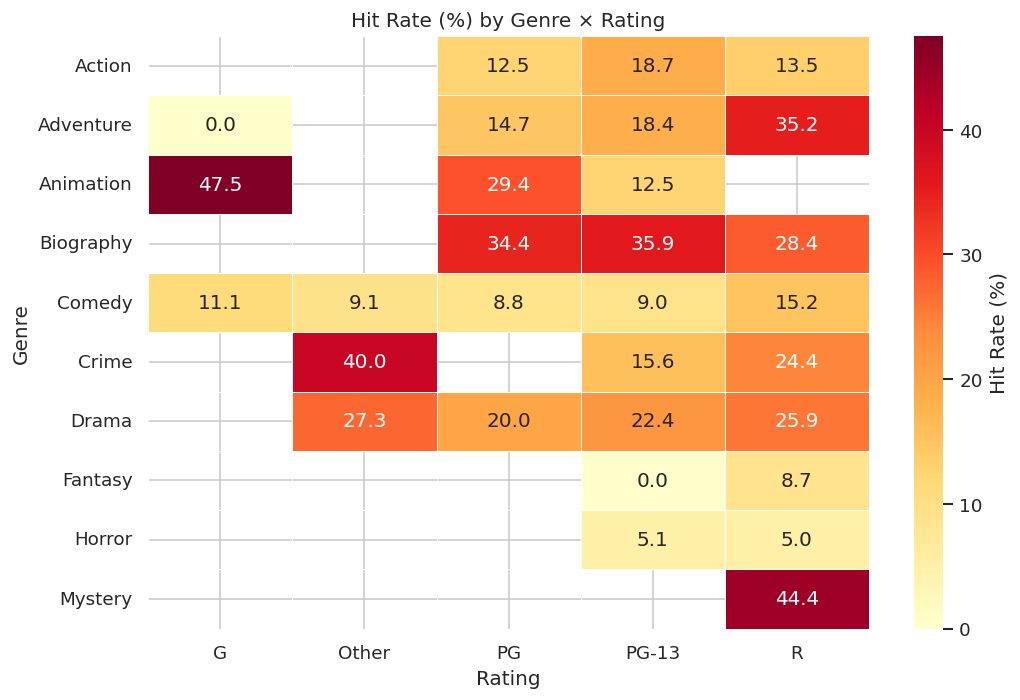

,genre,rating,movie_count,hit_rate_pct,avg_score
0,Action,PG-13,498,18.7,6.18
1,Action,R,540,13.5,6.32
2,Action,PG,112,12.5,5.87
3,Adventure,R,54,35.2,6.78
4,Adventure,PG-13,49,18.4,6.33
5,Adventure,PG,116,14.7,5.94
6,Adventure,G,9,0.0,5.60
7,Animation,G,59,47.5,6.93
8,Animation,PG,143,29.4,6.64
9,Animation,PG-13,8,12.5,6.10


In [14]:
q9 = sql("""
    SELECT
        genre,
        rating_clean                    AS rating,
        COUNT(*)                        AS movie_count,
        ROUND(AVG(hit) * 100, 1)        AS hit_rate_pct,
        ROUND(AVG(score), 2)            AS avg_score
    FROM movies
    WHERE budget IS NOT NULL
      AND gross  IS NOT NULL
    GROUP BY genre, rating_clean
    HAVING movie_count >= 5
    ORDER BY genre, hit_rate_pct DESC
""", conn)

q9.to_csv('sql_genre_rating_crosstab.csv', index=False)

# Pivot for heatmap
pivot = q9.pivot_table(index='genre', columns='rating', values='hit_rate_pct', aggfunc='mean')

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Hit Rate (%)'})
ax.set_title('Hit Rate (%) by Genre × Rating')
ax.set_xlabel('Rating')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig('sql_genre_rating_heatmap.png', bbox_inches='tight')
plt.show()

q9.head(20)

---
## Query 10 — Window Function: Running Cumulative Gross by Year (per genre)

Rows returned: 203


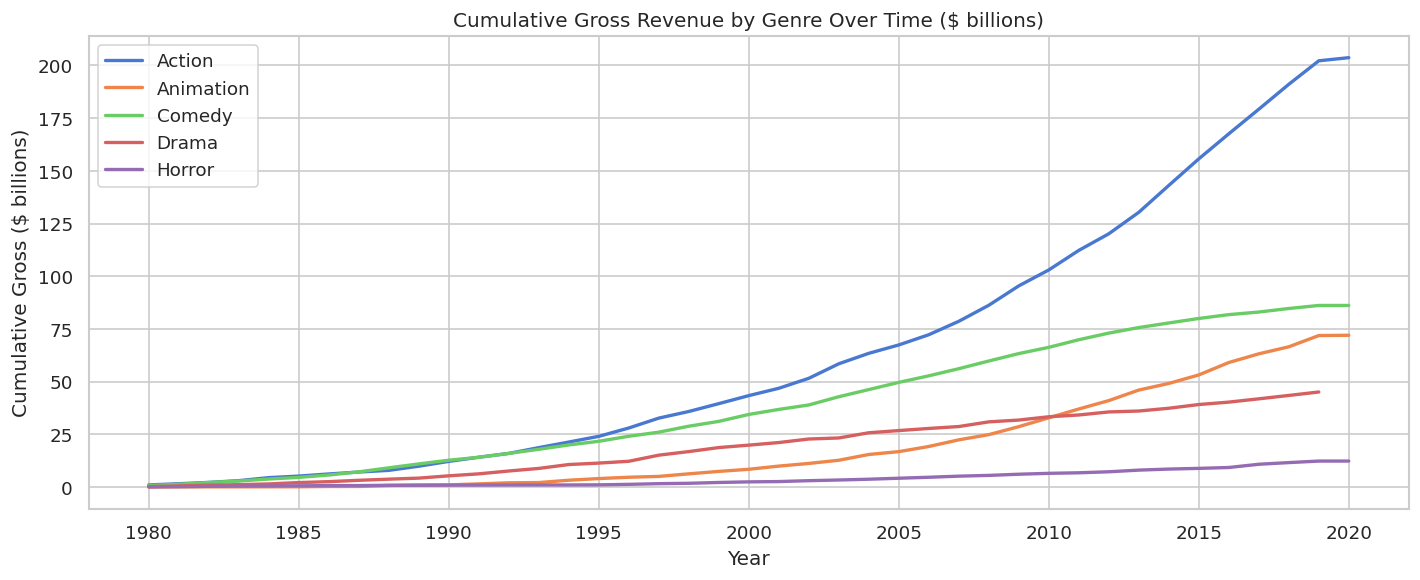

In [15]:
# SQLite supports window functions since version 3.25 (2018)
# This is available in Colab's Python 3.x environments

q10 = sql("""
    SELECT
        year,
        genre,
        ROUND(SUM(gross) / 1e9, 3)  AS yearly_gross_B,
        ROUND(
            SUM(SUM(gross)) OVER (PARTITION BY genre ORDER BY year)
            / 1e9, 3
        )                           AS cumulative_gross_B
    FROM movies
    WHERE gross IS NOT NULL
      AND genre IN ('Action', 'Comedy', 'Drama', 'Animation', 'Horror')
    GROUP BY year, genre
    ORDER BY genre, year
""", conn)

q10.to_csv('sql_cumulative_gross.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 5))
for genre, group in q10.groupby('genre'):
    ax.plot(group['year'], group['cumulative_gross_B'], label=genre, linewidth=2)

ax.set_title('Cumulative Gross Revenue by Genre Over Time ($ billions)')
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Gross ($ billions)')
ax.legend()
plt.tight_layout()
plt.savefig('sql_cumulative_gross.png', bbox_inches='tight')
plt.show()

---
## Summary — What SQL Revealed

In [16]:
summary = sql("""
    SELECT
        COUNT(*)                             AS total_movies,
        ROUND(AVG(hit) * 100, 1)             AS overall_hit_rate_pct,
        ROUND(AVG(score), 2)                 AS avg_score,
        ROUND(AVG(gross) / 1e6, 1)           AS avg_gross_M,
        ROUND(AVG(budget) / 1e6, 1)          AS avg_budget_M,
        ROUND(AVG(roi), 2)                   AS avg_roi,
        MIN(year)                            AS earliest_year,
        MAX(year)                            AS latest_year
    FROM movies
    WHERE budget IS NOT NULL
      AND gross  IS NOT NULL
""", conn)

print('=== DATASET SUMMARY (SQL) ===')
for col in summary.columns:
    print(f'  {col:<25} {summary[col].values[0]}')

print()
print('=== FILES EXPORTED ===')
import glob
for f in sorted(glob.glob('sql_*.csv')):
    print(f'  {f}')

Rows returned: 1
=== DATASET SUMMARY (SQL) ===
  total_movies              4326
  overall_hit_rate_pct      17.7
  avg_score                 6.33
  avg_gross_M               108.9
  avg_budget_M              37.3
  avg_roi                   7.49
  earliest_year             1980
  latest_year               2020

=== FILES EXPORTED ===
  sql_budget_tiers.csv
  sql_critical_hits.csv
  sql_cumulative_gross.csv
  sql_decade_trends.csv
  sql_directors_hits.csv
  sql_genre_hit_rate.csv
  sql_genre_rating_crosstab.csv
  sql_rating_analysis.csv
  sql_top10_grossing.csv
  sql_top_companies.csv


In [17]:
# Always close the connection when done
conn.close()
print('SQLite connection closed ✅')
print()
print('Next step: Notebook 05 — Predictive Model')
print('Use movies_enriched.csv (from Notebook 03) as the model input.')

SQLite connection closed ✅

Next step: Notebook 05 — Predictive Model
Use movies_enriched.csv (from Notebook 03) as the model input.
